In [1]:
 import matplotlib.pyplot as plt

In [2]:
import pandas as pd
data=pd.read_excel(r'D:\creep rupture\添加高温测试和高应力\normalizedtrainingdataTF.xlsx')

In [3]:
data.columns

Index(['C', 'Si', 'Mn', 'P', 'S', 'Mo', 'Cu', 'B', 'Ti', 'N', 'Nb', 'Zr', 'Co',
       'ρ(g/㎤)', 'χ', '∆χ', 'TeWQ(℃)', 'TiWQ(h)', 'TiFC(h)', 'TiOQ(h)',
       'TiAr(h)', 'Rockwell hardness(HRC)', 'Austenite grain size number',
       'cconverter', 'converter', 'high', 'pierced', 'Test Temparature(℃)',
       '0.2% Proof Stress(MPa)', 'Test stress(MPa)', 'Elongation(%)',
       'Reduction of Area(%)', 'Tensile Strength(Mpa)', 'Time to Rupture(h)'],
      dtype='object')

## Tensile strength

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

data.dropna(subset=['Tensile Strength(Mpa)'], inplace=True)  # 删除空缺值

X = data.drop(columns=['Tensile Strength(Mpa)', 'Time to Rupture(h)'])
y = data['Tensile Strength(Mpa)']

estimator = RFR()

print("递归特征消除法和曲线图选取最优特征数量")

score = []
for i in range(1, 10, 1):
    selector = RFE(estimator, n_features_to_select=i, step=1)
    selector = selector.fit(X, y)
    print(selector.support_)
    print(selector.ranking_)
    print(selector.n_features_)
    once = cross_val_score(estimator, selector.transform(X), y, cv=10).mean()
    score.append(once)

print(max(score), (score.index(max(score)) * 1) + 1)
print(score)

递归特征消除法和曲线图选取最优特征数量
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True False False False]
[13 20  8 18 19 12 22 17 21 11 27 32  5 16  3 15 23 26 28 24 31 14  7 30
 29 10 25  6  1  2  9  4]
1
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True  True False False]
[16 15  9 18 19  7 21 17 20 11 25 28  4 14  2 13 22 23 27 26 31 12  6 30
 29 10 24  5  1  1  8  3]
2
[False False False False False False False False False False False False
 False False  True False False False False False False False False False
 False False False False  True  True False False]
[13 15  6 17 18  9 20 14 19 10 25 29  3 16  1 12 21 22 27 23 28 11  5 30
 26  8 24  4  1  1  7  2]
3
[False False False False False False False False False False False False
 False False  Tr

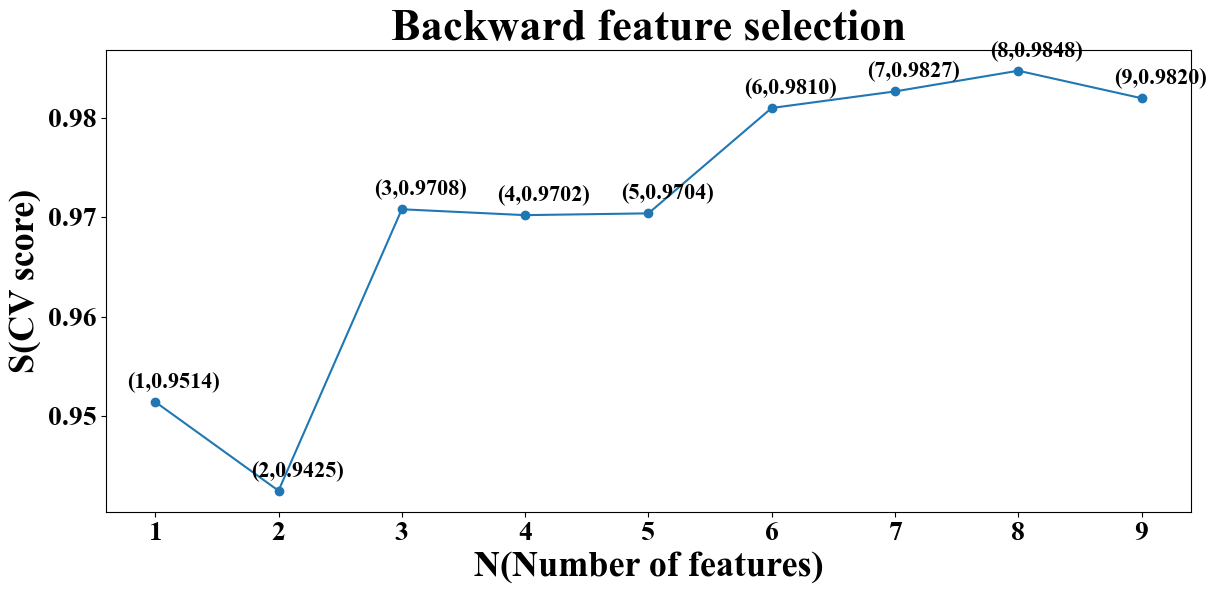

In [6]:
plt.figure(figsize=[14, 6])
plt.plot(range(1, 10, 1), score, marker='o')
plt.xlabel('N(Number of features)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
plt.ylabel('S(CV score)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
for xy in zip(range(1, 10, 1), score):
    plt.annotate("(%s,%.4f)" % xy, xy=xy, xytext=(-20, 10),textcoords='offset points',weight='bold',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':16
       })
plt.title('Backward feature selection',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':32
       })
plt.xticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.yticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.show()

## Time to Rupture

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

data.dropna(subset=['Time to Rupture(h)'], inplace=True)  # 删除空缺值

X = data.drop(columns=['Tensile Strength(Mpa)', 'Time to Rupture(h)'])
y = data['Time to Rupture(h)']

estimator = RFR()

print("递归特征消除法和曲线图选取最优特征数量")

score = []
for i in range(1, 10, 1):
    selector = RFE(estimator, n_features_to_select=i, step=1)
    selector = selector.fit(X, y)
    print(selector.support_)
    print(selector.ranking_)
    print(selector.n_features_)
    once = cross_val_score(estimator, selector.transform(X), y, cv=10).mean()
    score.append(once)

print(max(score), (score.index(max(score)) * 1) + 1)
print(score)

递归特征消除法和曲线图选取最优特征数量
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False  True False]
[13  9  4 14 18 16 17 20 19  8 23 25 28  6 15 12 24 22 27 31 32 11 10 30
 26 29 21  3  7  2  1  5]
1
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False  True  True False]
[12  8  4 15 18 11 13 20 16  7 22 25 24  5 17 14 21 23 27 29 31 10  9 28
 26 30 19  2  6  1  1  3]
2
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False  True False  True  True False]
[11  7  2 12 18 16 13 19 15  6 20 25 23  4 14 10 21 22 26 29 30  9  8 28
 24 27 17  1  5  1  1  3]
3
[False False False False False False False False False False False False
 False False Fal

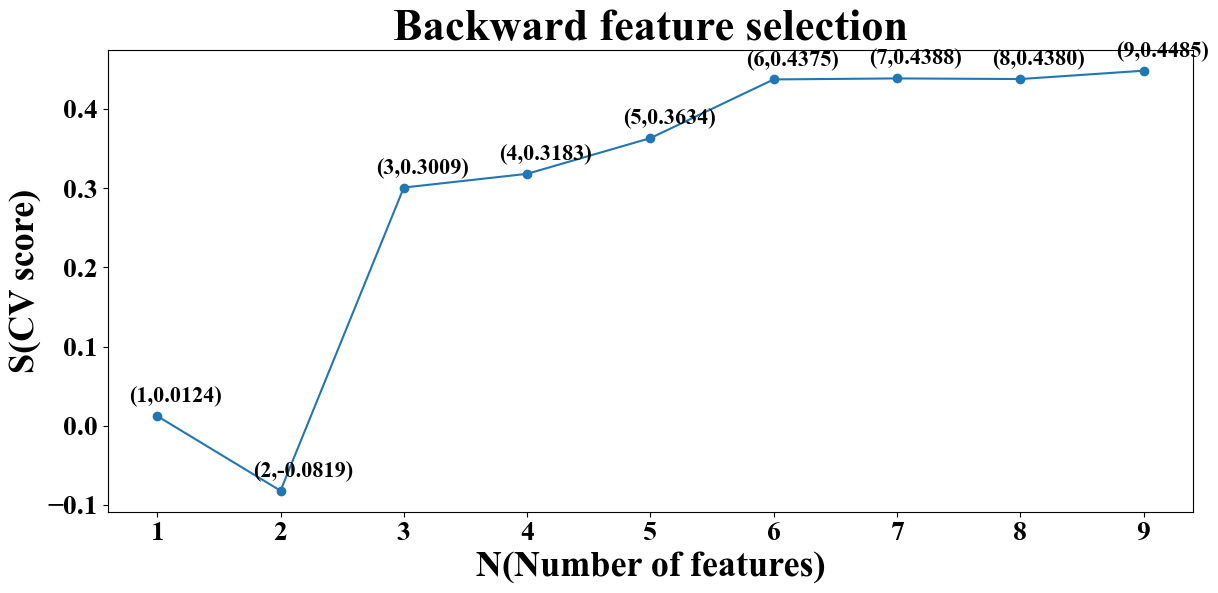

In [8]:
plt.figure(figsize=[14, 6])
plt.plot(range(1, 10, 1), score, marker='o')
plt.xlabel('N(Number of features)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
plt.ylabel('S(CV score)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
for xy in zip(range(1, 10, 1), score):
    plt.annotate("(%s,%.4f)" % xy, xy=xy, xytext=(-20, 10),textcoords='offset points',weight='bold',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':16
       })
plt.title('Backward feature selection',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':32
       })
plt.xticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.yticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.show()